# Exploratory Data Analysis

In [21]:
import re
import warnings
import datetime
import unicodedata
import numpy as np
import pandas as pd
import seaborn as sns
from datetime import date, timedelta
from matplotlib import pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from wordcloud import WordCloud
from collections import Counter

In [2]:
# Import

df = pd.read_csv('preprocessed_data.csv')
df['Date']     = pd.to_datetime(df['Date']).dt.date
df['Creation'] = pd.to_datetime(df['Creation']).dt.date
df.sort_values('Date', inplace=True)
df.info()
df.sample(10, random_state = 123)

<class 'pandas.core.frame.DataFrame'>
Index: 56219 entries, 0 to 56218
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       56219 non-null  object
 1   Comment    56219 non-null  object
 2   Reply      56219 non-null  int64 
 3   Retweet    56219 non-null  int64 
 4   Like       56219 non-null  int64 
 5   Quote      56219 non-null  int64 
 6   Creation   56219 non-null  object
 7   Place      39387 non-null  object
 8   Followers  56219 non-null  int64 
 9   Leader     56219 non-null  object
 10  Raw_Tweet  56219 non-null  object
dtypes: int64(5), object(6)
memory usage: 5.1+ MB


,Date,Comment,Reply,Retweet,Like,Quote,Creation,Place,Followers,Leader,Raw_Tweet
26017,2018-12-10,"['avoir', 'tjrs', 'avoir', 'bcp', 'respect', '...",1,0,0,0,2018-09-01,Kenya,16,Fayulu,@StanysBujakera @LubayaClaudel @DSESANGA @Ense...
32230,2018-12-12,"['rdc', 'candidat', 'maurice', 'masheke', 'inv...",0,0,0,0,2018-02-22,République Démocratique Du Con,112,Fayulu,Rdc : Le candidat Maurice Masheke invite les c...
8593,2018-11-26,"['hahaha', 'avoir', 'enterrer', 'papa', 'autru...",2,0,1,0,2016-02-09,RDC🇨🇩🇨🇩,34941,Fayulu,@tresinsolent @Brielyoka @YNdjoli @moise_katum...
43578,2018-12-19,"['ami', 'cela', 'être', 'distraction', 'reveni...",0,2,3,0,2017-02-24,République Démocratique Du Congo,290,Fayulu,@lec_2001 @damkup @jmilunga @juantedbelkas @Ed...
53894,2018-12-30,"['okufi', 'nayo', 'ndeko', 'ted', 'beleshay', ...",0,0,1,0,2016-05-10,Congo Kinshasa,1307,Tshisekedi,@juantedbelkas @MartinFayulu @fatshi13 Okufi n...
43321,2018-12-19,"['cher', 'ami', 'rejoindre', 'vérité', 'avant'...",0,0,0,0,2013-02-01,NaN,1962,Fayulu,"Chers amis, rejoignez la vérité avant qu’il ne..."
36759,2018-12-15,"['fayulu', 'être', 'porte', 'parole', 'muzito'...",0,0,0,0,2018-09-01,NaN,2748,Fayulu,@BNC_2012 @INSOUMISERDC @LithoLeja Fayulu en s...
17951,2018-12-05,"['accueil', 'triompant', 'exceptionnel', 'mart...",0,0,3,0,2012-01-23,United Kingdom,851,Fayulu,L’ACCUEIL TRIOMPANT ET EXCEPTIONNEL DE MARTIN ...
29058,2018-12-11,"['grand', 'mobilisation', 'accueillir', 'marti...",0,0,0,0,2013-08-30,RDCONGO,477,Fayulu,Grande mobilisation pour accueillir Martin Fay...
22908,2018-12-08,"['emmanuel', 'shadary', 'reste', 'sou', 'sanct...",0,3,1,0,2015-01-13,NaN,567,Ramazani,EMMANUEL SHADARY RESTE SOUS SANCTIONS .\n\nDes...


## Usual plots

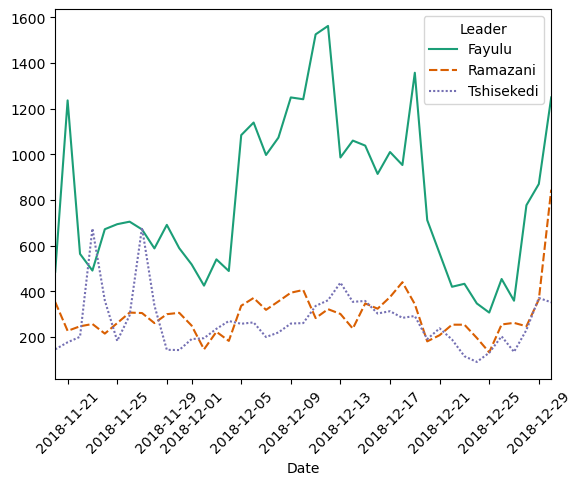

In [3]:
# Number of tweets per leader

sns.lineplot(data = df.pivot_table(values = "Quote", columns = "Leader", index = "Date", aggfunc = "count"),
             palette = 'Dark2')
#plt.title('Evolution du nombre de tweets par leader')
plt.xticks(rotation=45)
plt.xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])
plt.savefig('evolution_of_the_number_of_tweets_per_leader.pdf', bbox_inches = 'tight', pad_inches = .1);

Leader
Fayulu        33041
Ramazani      12196
Tshisekedi    10982
dtype: int64

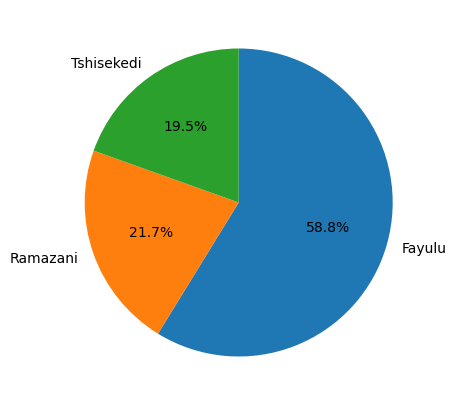

In [4]:
# Total number of tweets per leader

plt.figure(figsize = (5,5))
plt.pie(x = df['Leader'].value_counts(normalize = True, ascending = False), labels = df.groupby('Leader').size().index,
        autopct = '%2.1f%%', counterclock = False, startangle = 90)
plt.savefig('distribution_of_tweets_per_leader.pdf', bbox_inches = 'tight', pad_inches = .1);
df.groupby('Leader').size()

In [5]:
# Counting tweets per localization

location = df['Place'].value_counts()
location = location.to_frame()
location.rename(columns = {'count':'Frequency'}, inplace = True)
location.index.names = ['Place']
location.reset_index(inplace = True)
location.sample(10)

,Place,Frequency
1065,"Melbourne, Victoria Australia",3
1388,europe,1
1499,Butembo,1
635,"Kinshasa,RDC",6
16,Worldwide citizen from Bumba,332
229,RD Congo,24
977,"Québec,Qc",3
459,DRC🇨🇩_🇨🇦_,10
581,Kinshasa (RDC),7
647,Lubumbashi - DRC,6


In [6]:
# Place string normalization (lowercase, remove accents & punctuation, collapse spaces)

def place_normalization(s):
    if pd.isna(s):
        return ""
    s = str(s)
    # unicode normalize and drop accents
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("ascii")
    # lowercase, replace non-alphanum by space, collapse spaces
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s-]", " ", s)
    s = re.sub(r"[\s\-]+", " ", s).strip()
    return s

In [7]:
# Canonical map: canonical_name -> list of substrings to match (normalized)

canonical_map = {
    "DRC":            ["rdc", "dr congo", "democratic republic", "democratic republic of congo",
                       "republique democratique du con"],
    "Kinshasa":       ["kinshasa", r"\bkin\b", "kin"],
    "Goma":           ["goma", "nord kivu", "nord-kivu", "nordkivu"],
    "Bukavu":         ["bukavu"],
    "Beni":           ["beni"],
    "Bunia":          ["bunia", "unia"],
    "Butembo":        ["butembo"],
    "Lubumbashi":     ["lubumbashi"],
    "Kisangani":      ["kisangani"],
    "Mbuji-Mayi":     ["mbuji", "mbuji-mayi", "mbuji mayi"],
    "Likasi":         ["likasi"],
    "Kolwezi":        ["kolwezi"],
    "Kalemie":        ["kalemie", "alemi"],
    "Kananga":        ["kananga"],
    "Kikwit":         ["kikwit"],
    "Matadi":         ["matadi"],
    "Uvira":          ["uvira"],
    "Bumba":          ["bumba"],
    "Bandundu":       ["bandundu"],
    # international / capitals (examples)
    "France":         ["france", "paris"],
    "Belgium":        ["brussel", "bruxel", "bruxelles", "belgique", "belgi"],
    "USA":            ["united states", "usa", "tats unis", "states", "new-york", "new york", "ny"],
    "Canada":         ["canada", "montreal", "quebec", "ottawa", "ontario"],
    "Angola":         ["luanda", "angola", "ngola"],
    "Rwanda":         ["kigali", "rwanda"],
    "South Africa":   ["cape town", "cape", "johannesburg", "south africa"],
    "Morocco":        ["casablanca", "rabat", "marrakech", "maroc"],
    "Senegal":        ["dakar", "senegal"],
    "Switzerland":    ["geneva", "geneve", "suisse", "zurich", "lausanne"],
    "United Kingdom": ["london", "england", "uk"],
    "Italy":          ["rome", "roma", "italie", "itali"],
    "Germany":        ["germany", "deutschland", "frankfurt"],
    # add or refine entries as needed...
}

In [8]:
# Vectorized cleaning and mapping
warnings.filterwarnings("ignore")
location['Place'] = location['Place'].apply(place_normalization)

# Applying canonical_map with priority order (first match wins)
location['Std_Place'] = pd.NA  # column to hold standardized canonical name

for canonical, keywords in canonical_map.items():
    # build regex pattern (word-boundary friendly)
    # escape keywords to be safe but allow small word matches
    escaped = [re.escape(k) for k in keywords]
    pattern = r"(" + r"|".join(escaped) + r")"
    mask = location['Place'].str.contains(pattern, na=False)
    # assign only where not already assigned (preserve priority)
    location.loc[mask & location['Std_Place'].isna(), 'Std_Place'] = canonical
    
# fallback: if nothing matched, use a cleaned title-case original (or keep as "Unknown")
location.loc[location['Std_Place'].isna(), 'Std_Place'] = location.loc[location['Std_Place'].isna(), 'Place'].str.strip().replace('', 'Unknown').str.title()

In [9]:
# Final grouping and aggregation after handling duplicate locations

location_clean = (
    location.groupby('Std_Place', as_index=False)
       .agg(Place=('Place','first'), Frequency=('Frequency','sum'))
       .sort_values('Frequency', ascending=False)
)

# replace original variable if desired
location = location_clean
location.sample(10)

,Std_Place,Place,Frequency
517,Nidau Schweiz,nidau schweiz,1
669,Shaanxi Republique Populaire,shaanxi republique populaire,1
679,Somewhere In The World,somewhere in the world,2
777,Www Plainsouls Com Oneafrica,www plainsouls com oneafrica,1
62,Atlanta Ga,atlanta ga,14
26,Accra Ghana,accra ghana,1
151,Centre Cameroon,centre cameroon,1
647,Rwanda,republique du rwanda,47
24,Abuja Nigeria,abuja nigeria,59
727,Tres Loin De Toi,tres loin de toi,7


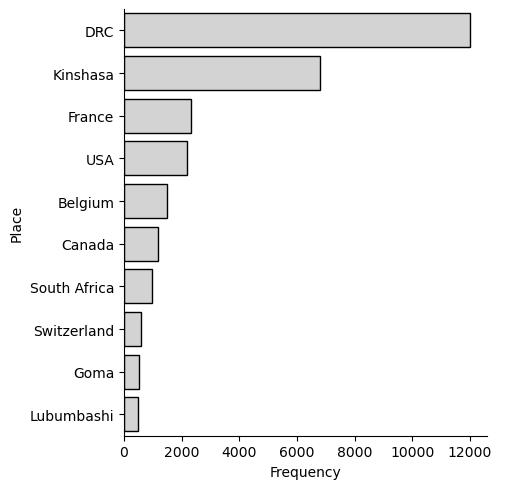

In [10]:
# Tweets per localization

sns.catplot(data=location[0:10], y="Std_Place", x="Frequency", kind="bar", color="lightgray", edgecolor="black")
plt.ylabel('Place')
plt.savefig('tweets_location.pdf', bbox_inches = 'tight', pad_inches = .1);

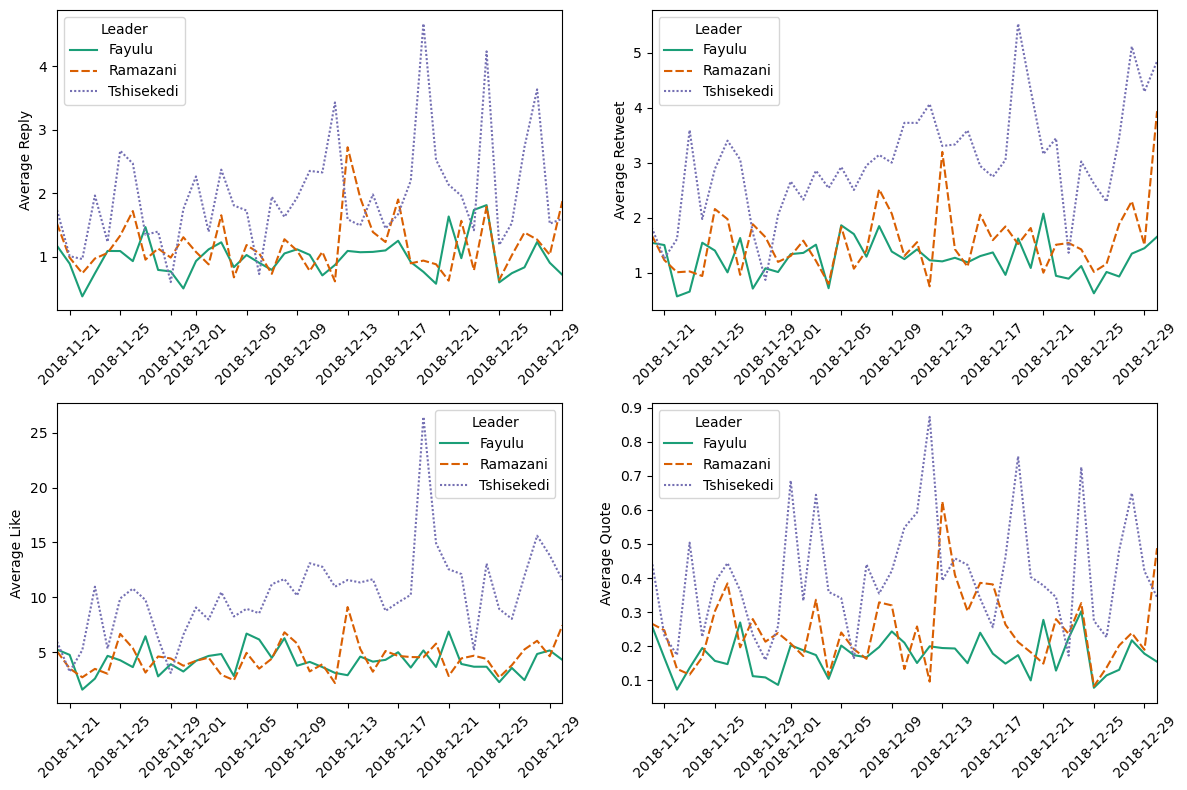

In [11]:
# Average amplification of tweets by leader over time

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(['Reply', 'Retweet', 'Like', 'Quote']):
    sns.lineplot(data=df.pivot_table(values=metric, columns='Leader', index='Date', aggfunc='mean'), 
                 ax=axes[i], palette='Dark2')
    axes[i].set_ylabel(f'Average {metric}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlim([datetime.date(2018, 11, 20), datetime.date(2018, 12, 30)])

plt.tight_layout()
plt.savefig('engagement_metrics_evolution.pdf', bbox_inches='tight', pad_inches=.1);

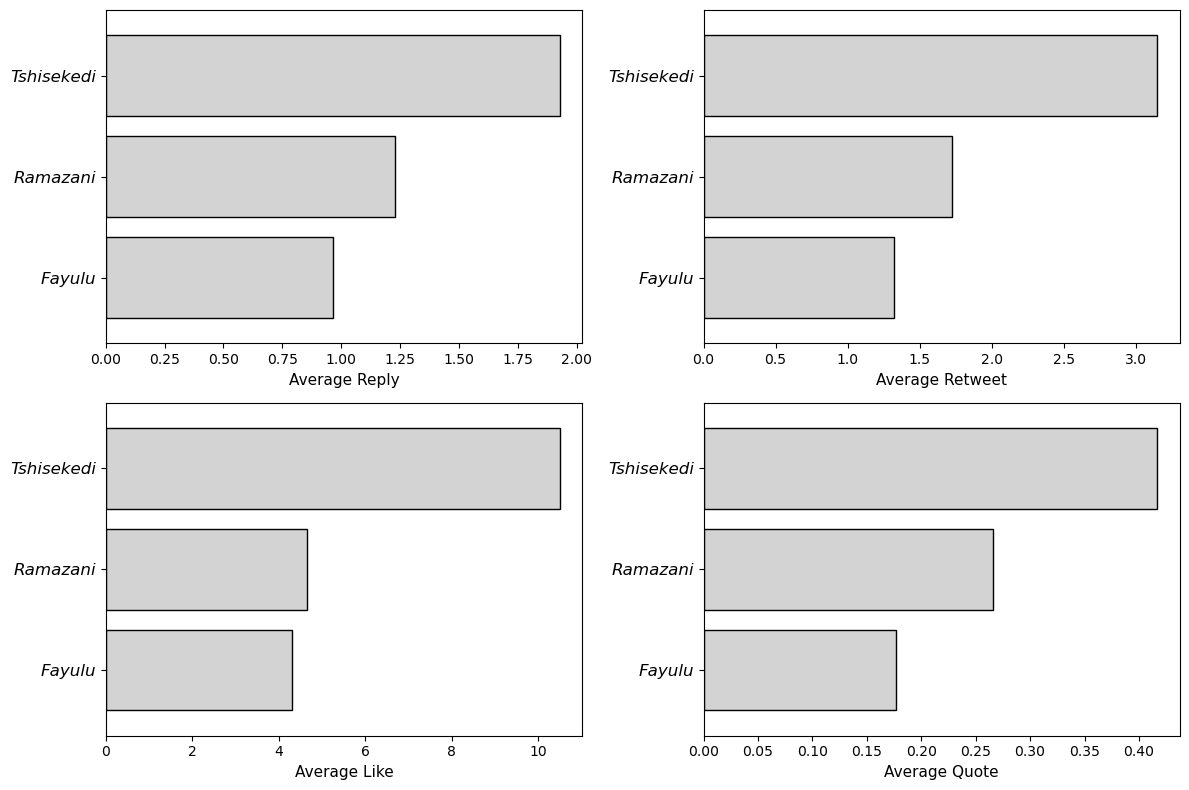

In [12]:
# Overall average engagement metrics by leader

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(['Reply', 'Retweet', 'Like', 'Quote']):
    df.groupby('Leader')[metric].mean().sort_values().plot.barh(ax=axes[i], 
                                                               color='lightgrey', 
                                                               edgecolor='black',
                                                               width=0.8)
    #axes[i].set_title(f'Average {metric} per Leader')
    axes[i].set_xlabel(f'Average {metric}', fontsize=11)
    axes[i].set_ylabel('')
    axes[i].set_yticklabels([label.get_text() for label in axes[i].get_yticklabels()], style='italic', fontsize=12)

plt.tight_layout()
plt.savefig('overall_engagement_averages.pdf', bbox_inches='tight', pad_inches=.1);

## Tweets clustering by Topics

In [13]:
# Set visual style
sns.set_palette("husl")

# 1. DEFINE RELEVANT THEMES FOR DRC ELECTIONS

PREDEFINED_THEMES = {
    'Security & Conflict': ['sécurité', 'conflit', 'paix', 'violence', 'groupe armé', 'm23', 'adf', 'monusco', 'est', 'force'],
    #'Economy & Jobs': ['économie', 'emploi', 'chômage', 'pauvreté', 'inflation', 'développement', 'franc congolais', 'prix', 'travail'],
    #'Corruption & Governance': ['corruption', 'gouvernance', 'transparence', 'vol', 'détournement', 'crise', 'état', 'justice', 'scandale'],
    'Election Process': ['élection', 'vote', 'candidat', 'cena', 'ceni', 'bulletin', 'fraude', 'campagne', 'scrutin', 'électoral'],
    #'Foreign Relations/Extractives': ['rwanda', 'ouganda', 'onu', 'international', 'mine', 'minier', 'cobalt', 'cuivre', 'étranger', 'ressource'],
    'Social Services': ['santé', 'éducation', 'école', 'hôpital', 'eau', 'électricité', 'social', 'service public']
}

def prepare_text_for_lda(df, text_column='Comment'):
    """
    Convert preprocessed tokens to strings for LDA.
    """
    if isinstance(df[text_column].iloc[0], list):
        df['text_for_lda'] = df[text_column].apply(lambda x: ' '.join(x))
    else:
        df['text_for_lda'] = df[text_column]
    return df

def map_topic_to_theme(topic_keywords, predefined_themes):
    """
    Map LDA topic keywords to the best-matching predefined theme.
    """
    best_theme = list(predefined_themes.keys())[0]  # Default to first theme
    best_score = 0
    for theme, keywords in predefined_themes.items():
        score = sum(1 for kw in keywords if any(kw in word for word in topic_keywords))
        if score > best_score:
            best_score = score
            best_theme = theme
    # No 'Other' category: always return the best match
    return best_theme, best_score

In [14]:
# 2. GUIDED LDA ANALYSIS PIPELINE

def guided_lda_analysis(df, text_column='Comment', n_topics=12, top_n_words=15):
    """
    Main function: Performs LDA and maps results to predefined themes.
    """
    print("Preparing text and running LDA...")
    df = prepare_text_for_lda(df, text_column)
    texts = df['text_for_lda'].tolist()
    
    vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
    dtm = vectorizer.fit_transform(texts)
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, learning_method='online')
    lda.fit(dtm)
    
    feature_names = vectorizer.get_feature_names_out()
    lda_topics_keywords = []
    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[:-top_n_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        lda_topics_keywords.append(top_words)
    
    topic_to_theme_map = {}
    for topic_idx, keywords in enumerate(lda_topics_keywords):
        theme, score = map_topic_to_theme(keywords, PREDEFINED_THEMES)
        topic_to_theme_map[topic_idx] = theme
        print(f"LDA Topic {topic_idx:2d} -> '{theme}' (score: {score})")
    
    doc_topic_dist = lda.transform(dtm)
    df['dominant_topic'] = doc_topic_dist.argmax(axis=1)
    df['dominant_theme'] = df['dominant_topic'].map(topic_to_theme_map)
    df['topic_confidence'] = doc_topic_dist.max(axis=1)
    
    return df, lda, dtm, vectorizer, topic_to_theme_map, lda_topics_keywords

In [15]:
# 3. CREATE THE SORTED BAR PLOT (Theme Distribution)

def create_sorted_bar_plot(df):
    """
    Creates a single 'Distribution of Themes' plot with percentage labels.
    """
    theme_counts = df['dominant_theme'].value_counts()
    total_tweets = len(df)
    theme_percentages = (theme_counts / total_tweets * 100).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Set3(np.linspace(0, 1, len(theme_percentages)))
    bars = plt.barh(range(len(theme_percentages)), theme_percentages.values, color=colors, edgecolor='black')
    plt.yticks(range(len(theme_percentages)), theme_percentages.index, style='italic', fontsize=12)
    plt.gca().invert_yaxis()
    plt.xlabel('Percentage of Tweets (%)', fontsize=11)
    plt.title('')
    #plt.title('Distribution of Themes', fontsize=14, fontweight='bold')
    
    for bar, percentage in zip(bars, theme_percentages.values):
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f'{percentage:.1f}%', va='center', ha='left', fontsize=11)
    plt.tight_layout()
    plt.savefig('theme_distribution.pdf', bbox_inches='tight', pad_inches=.1)
    plt.show()
    return theme_counts

In [16]:
# 4. KEYWORD FREQUENCY BY THEME (Horizontal Bar Chart)

def plot_keyword_frequency(df):
    """
    Plots the frequency of PREDEFINED keywords within each theme as a percentage.
    """
    print("\nGenerating 'Predefined Keyword Frequency by Theme' plot...")
    
    themes_sorted = sorted(PREDEFINED_THEMES.keys())
    n_themes = len(themes_sorted)
    
    fig, axes = plt.subplots(1, n_themes, figsize=(12, 6))
    if n_themes == 1:
        axes = [axes]
    
    for idx, theme in enumerate(themes_sorted):
        ax = axes[idx]
        keywords = PREDEFINED_THEMES[theme]
        theme_tweets = df[df['dominant_theme'] == theme]
        total_in_theme = len(theme_tweets)
        
        keyword_counts = []
        keyword_labels = []
        for kw in keywords:
            # Count tweets in this theme where the keyword appears
            count = theme_tweets['text_for_lda'].str.contains(kw, case=False, na=False).sum()
            percentage = (count / total_in_theme * 100) if total_in_theme > 0 else 0
            keyword_counts.append(percentage)
            keyword_labels.append(kw)
        
        # Sort keywords by percentage within this theme (descending)
        sorted_indices = np.argsort(keyword_counts)[::-1]
        sorted_counts = [keyword_counts[i] for i in sorted_indices]
        sorted_labels = [keyword_labels[i] for i in sorted_indices]
        
        y_pos = np.arange(len(sorted_labels))
        bars = ax.barh(y_pos, sorted_counts, color=plt.cm.Set3(idx / max(1, n_themes-1)), alpha=0.8, edgecolor='black')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(sorted_labels, style='italic', fontsize=12)
        ax.invert_yaxis()
        ax.set_xlabel('Percentage of Theme Tweets (%)')
        ax.set_title(f'Theme: {theme}', fontweight='bold')
        ax.set_xlim([0, max(sorted_counts) * 1.2 if max(sorted_counts) > 0 else 100])
        
        for bar, count in zip(bars, sorted_counts):
            width = bar.get_width()
            ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                   f'{count:.2f}%', va='center', fontsize=10)
    
    plt.suptitle('')
    #plt.suptitle('Keyword Frequency by Theme (% of Theme Tweets)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('keyword_by_theme.pdf', bbox_inches='tight', pad_inches=.1)
    plt.show()

In [17]:
# 5. WORD CLOUDS BY THEME

def generate_wordclouds_by_theme(df):
    """
    Creates a word cloud for each theme from the aggregated tweet text.
    """
    print("\nGenerating 'Word Clouds by Theme'...")
    themes = sorted(df['dominant_theme'].unique())
    n_themes = len(themes)
    
    fig, axes = plt.subplots(1, n_themes, figsize=(5 * n_themes, 5))
    if n_themes == 1:
        axes = [axes]
    
    for idx, theme in enumerate(themes):
        ax = axes[idx]
        theme_text = ' '.join(df[df['dominant_theme'] == theme]['text_for_lda'].fillna(''))
        if theme_text.strip():
            wordcloud = WordCloud(width=400, height=350, background_color='white',
                                  max_words=50, colormap='viridis', prefer_horizontal=0.7).generate(theme_text)
            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'Theme: {theme}', fontweight='bold')
        ax.axis('off')
    
    plt.suptitle('Word Clouds by Theme', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

In [18]:
# 6. T-SNE VISUALIZATION OF TWEETS BY THEME

def visualize_tsne_by_theme(dtm, theme_labels, perplexity=30.0):
    """
    Projects the document-term matrix into 2D using t-SNE, colored by theme.
    """
    print("\nGenerating 't-SNE Visualization of Tweets by Theme'...")
    if len(set(theme_labels)) < 2 or dtm.shape[0] < 10:
        print("Skipping t-SNE: Not enough data or themes.")
        return
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(perplexity, dtm.shape[0] - 1))
    tsne_results = tsne.fit_transform(dtm.toarray() if hasattr(dtm, 'toarray') else dtm)
    
    plt.figure(figsize=(12, 9))
    unique_themes = sorted(set(theme_labels))
    color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_themes)))
    
    for theme in unique_themes:
        indices = [i for i, lbl in enumerate(theme_labels) if lbl == theme]
        plt.scatter(tsne_results[indices, 0], tsne_results[indices, 1],
                   c=[color_map[unique_themes.index(theme)]], label=theme, alpha=0.7, s=40, edgecolors='k', linewidth=0.5)
    
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.title('')
    #plt.title('t-SNE Visualization of Tweets Colored by Theme')
    plt.legend(title='Themes', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('clustering_plot.pdf', bbox_inches='tight', pad_inches=.1)
    plt.show()

In [19]:
# 7. CLUSTERING QUALITY METRICS

def calculate_clustering_quality(df):
    """
    Calculates and prints key metrics for theme/cluster quality.
    """
    print("\n" + "="*60)
    print("CLUSTERING QUALITY METRICS")
    print("="*60)
    
    theme_counts = df['dominant_theme'].value_counts()
    avg_confidence = df['topic_confidence'].mean()
    total = len(df)
    
    print(f"Total Tweets Analyzed: {total}")
    print(f"Number of Themes Identified: {len(theme_counts)}")
    print(f"Average Assignment Confidence: {avg_confidence:.3f}")
    
    print("\nTheme Distribution (% of Total):")
    for theme in sorted(theme_counts.index):
        count = theme_counts[theme]
        percentage = (count / total) * 100
        print(f"  {theme:30s}: {count:4d} tweets ({percentage:5.1f}%)")
    
    if len(theme_counts) > 1:
        balance_std = theme_counts.std() / theme_counts.mean()
        print(f"\nCluster Balance (Std/Mean): {balance_std:.3f}")
        print("  (Closer to 0.0 indicates more balanced clusters)")

COMPREHENSIVE GUIDED LDA THEMATIC ANALYSIS
Preparing text and running LDA...
LDA Topic  0 -> 'Security & Conflict' (score: 0)
LDA Topic  1 -> 'Security & Conflict' (score: 0)
LDA Topic  2 -> 'Security & Conflict' (score: 0)
LDA Topic  3 -> 'Election Process' (score: 3)
LDA Topic  4 -> 'Election Process' (score: 2)
LDA Topic  5 -> 'Security & Conflict' (score: 1)
LDA Topic  6 -> 'Security & Conflict' (score: 0)
LDA Topic  7 -> 'Security & Conflict' (score: 0)
LDA Topic  8 -> 'Election Process' (score: 1)
LDA Topic  9 -> 'Election Process' (score: 1)
LDA Topic 10 -> 'Security & Conflict' (score: 0)
LDA Topic 11 -> 'Social Services' (score: 1)

VISUALIZATION PIPELINE

1. Generating 'Distribution of Themes' plot...


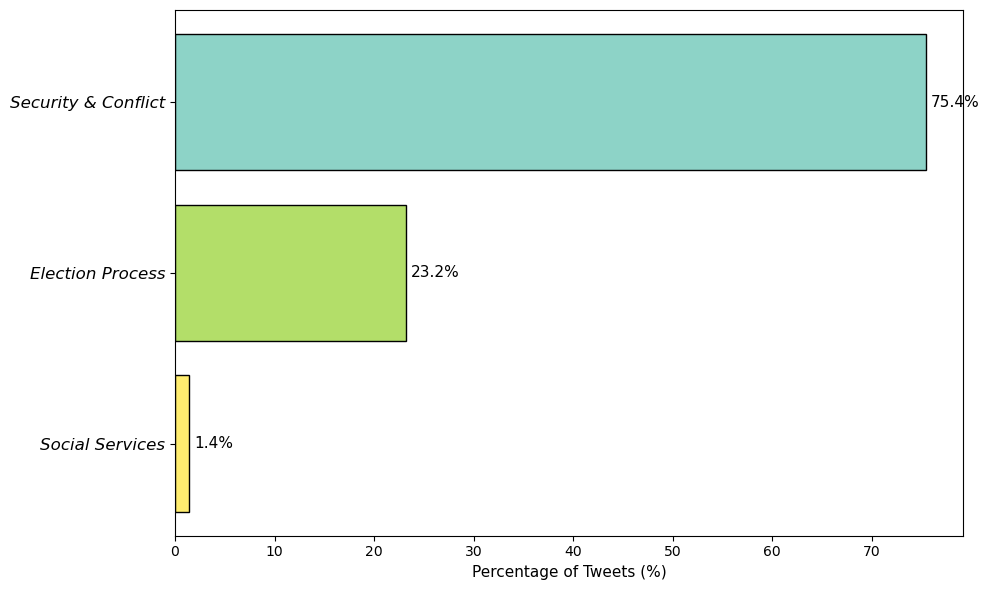


Generating 'Predefined Keyword Frequency by Theme' plot...


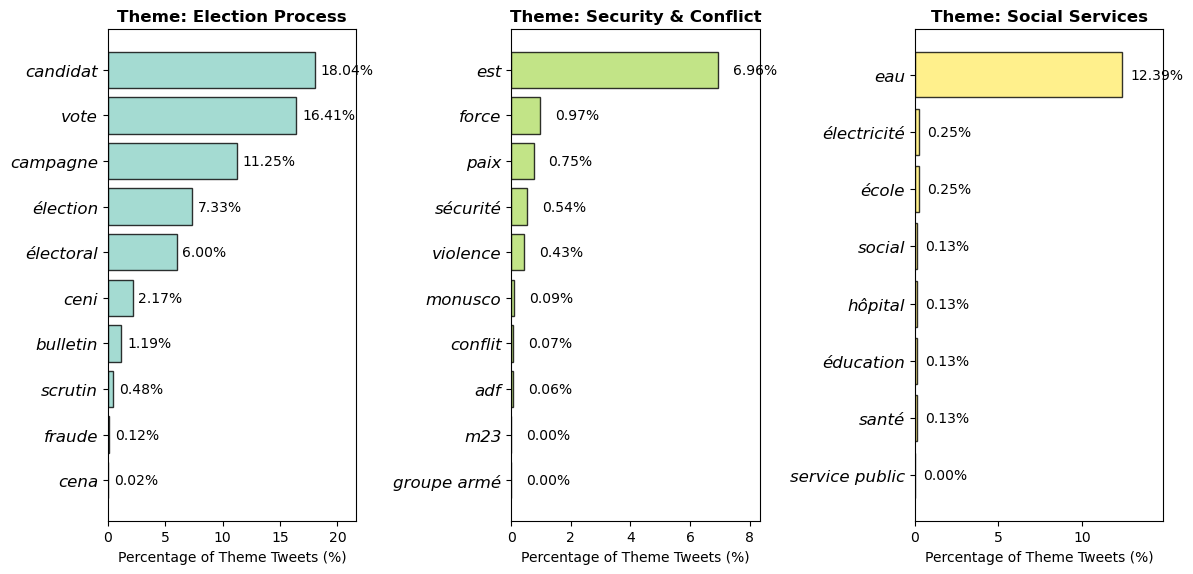


Generating 'Word Clouds by Theme'...


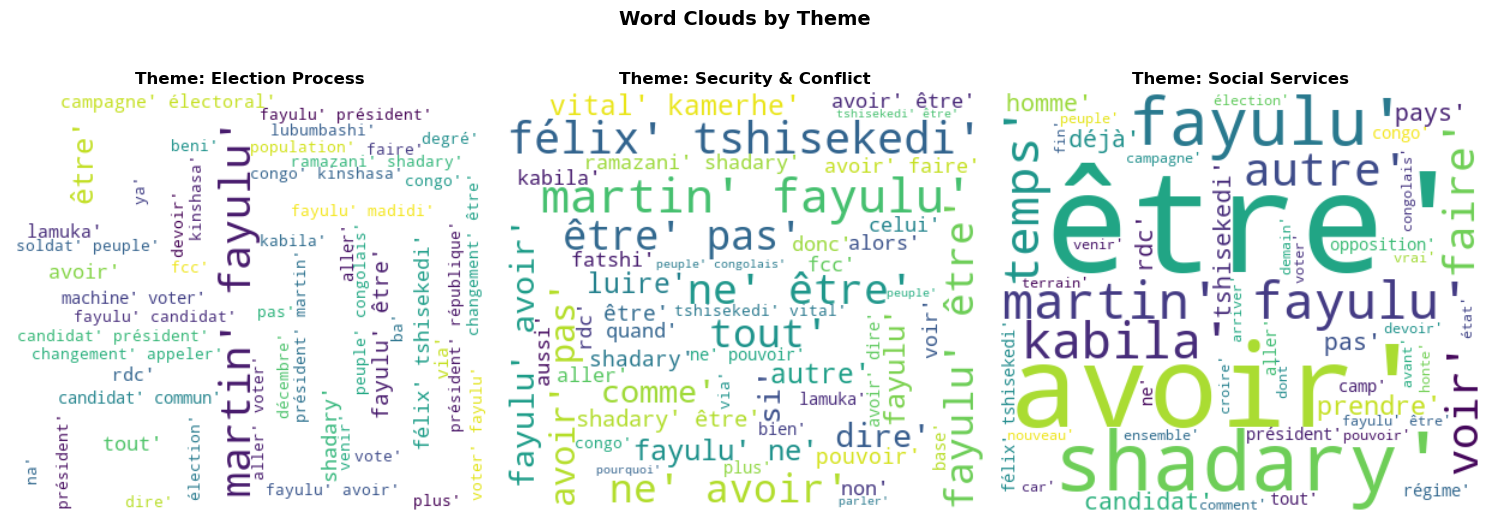


Generating 't-SNE Visualization of Tweets by Theme'...


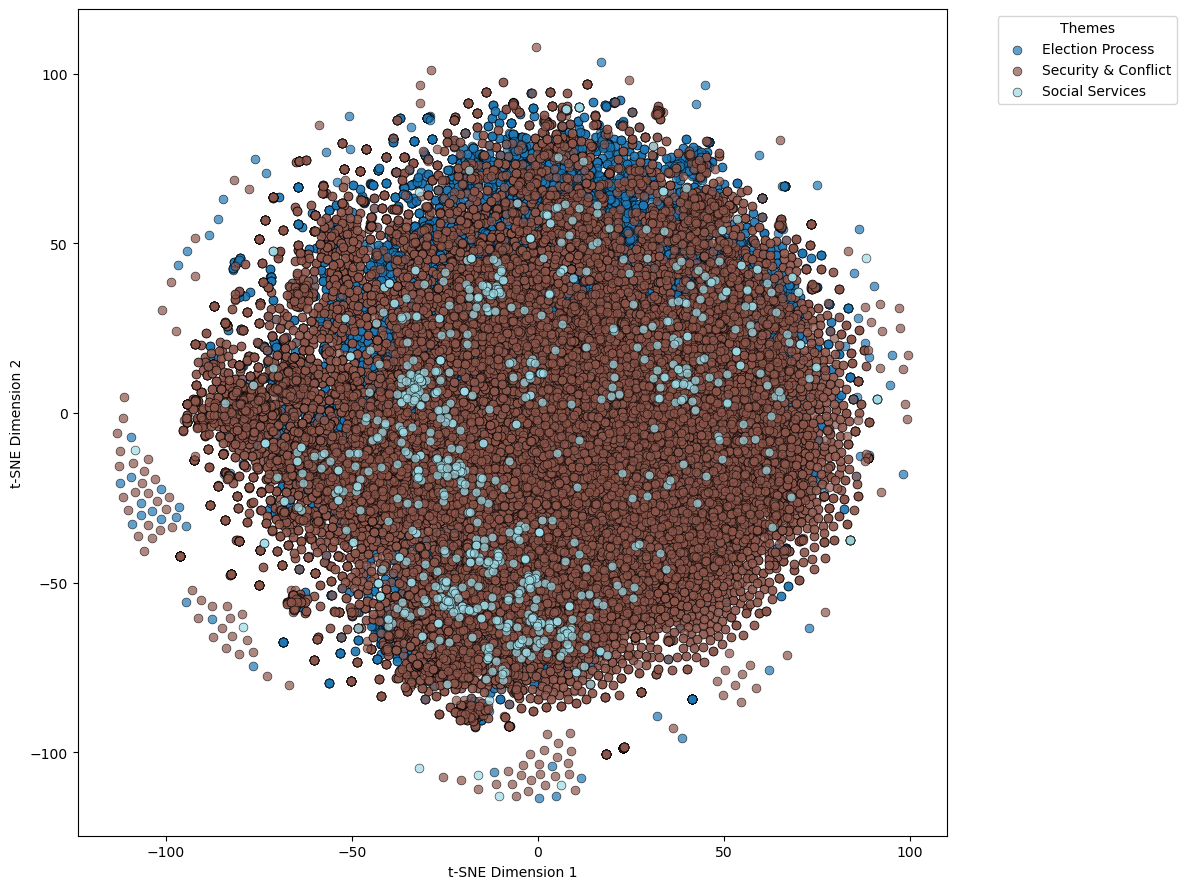


CLUSTERING QUALITY METRICS
Total Tweets Analyzed: 56219
Number of Themes Identified: 3
Average Assignment Confidence: 0.416

Theme Distribution (% of Total):
  Election Process              : 13025 tweets ( 23.2%)
  Security & Conflict           : 42395 tweets ( 75.4%)
  Social Services               :  799 tweets (  1.4%)

Cluster Balance (Std/Mean): 1.141
  (Closer to 0.0 indicates more balanced clusters)

Results saved to 'tweets_thematic_analysis_final.csv'

Sample of Results (First 10 tweets):
           Date                                                                                                                                                                                                                                                                                                                                                                               Comment       dominant_theme  topic_confidence
0    2018-11-20                                                   

In [20]:
# ------------------------------------------------------------
# MAIN EXECUTION PIPELINE
# ------------------------------------------------------------

if __name__ == "__main__":
    print("="*60)
    print("COMPREHENSIVE GUIDED LDA THEMATIC ANALYSIS")
    print("="*60)
    
    # Assuming your preprocessed DataFrame is named 'df'
    df_result, lda_model, dtm_matrix, vec, theme_map, topic_keywords = guided_lda_analysis(
        df, text_column='Comment', n_topics=12, top_n_words=15
    )
    
    print("\n" + "="*60)
    print("VISUALIZATION PIPELINE")
    print("="*60)
    
    # 1. DISTRIBUTION PLOT (Percentages)
    print("\n1. Generating 'Distribution of Themes' plot...")
    create_sorted_bar_plot(df_result)
    
    # 2. KEYWORD FREQUENCY PLOT
    plot_keyword_frequency(df_result)
    
    # 3. WORD CLOUDS
    generate_wordclouds_by_theme(df_result)
    
    # 4. T-SNE VISUALIZATION
    visualize_tsne_by_theme(dtm_matrix, df_result['dominant_theme'].tolist())
    
    # 5. QUALITY METRICS
    calculate_clustering_quality(df_result)
    
    # 6. SAVE RESULTS
    output_file = 'tweets_thematic_analysis_final.csv'
    df_result.to_csv(output_file, index=False, encoding='utf-8')
    print(f"\n" + "="*60)
    print(f"Results saved to '{output_file}'")
    print("="*60)
    
    # Display a final sample
    print("\nSample of Results (First 10 tweets):")
    sample_cols = [c for c in ['Date', 'Comment', 'dominant_theme', 'topic_confidence'] if c in df_result.columns]
    print(df_result[sample_cols].head(10).to_string())

### **t-Distributed Stochastic Neighbor Embedding (t-SNE) for Text Data Visualization**

**t-SNE** is a powerful, non-linear technique specifically designed for **visualizing high-dimensional data in a low-dimensional space** (typically 2D or 3D). It is exceptionally useful in Natural Language Processing (NLP) for exploring the "landscape" of text documents.

#### **Core Principle**
t-SNE works by converting similarities between data points in high dimensions (like the semantic meaning captured by text embeddings) into joint probabilities. It then aims to find a low-dimensional representation where these probabilities are preserved as faithfully as possible. Its key characteristic is that it focuses on **preserving local structure**—it tries to ensure that points that are close together in the high-dimensional space remain neighbors in the 2D/3D plot. This often results in visually distinct clusters for groups of similar documents.

#### **Why Use t-SNE for Text?**
Text data, once converted to numerical form (e.g., via TF-IDF, word2vec, or BERT embeddings), exists in an extremely high-dimensional space (hundreds or thousands of dimensions). This is impossible for humans to interpret directly. t-SNE acts as a sophisticated lens that projects this complex space down to 2D, allowing us to see:
*   **Inherent Groupings**: Whether documents naturally form clusters based on their semantic content.
*   **Relative Relationships**: How different themes or topics relate to or separate from each other.
*   **Outliers**: Documents that are semantically distinct from the main groups.

In this analysis, each tweet is first converted into a **semantic vector** (an embedding). t-SNE takes these hundreds of dimensions and finds a 2D arrangement where tweets discussing similar themes—like "Security" or "Politics"—are positioned near each other.

#### **t-SNE vs. PCA**
A common alternative is Principal Component Analysis (PCA). PCA is a **linear** method that preserves **global variance** (the large-scale structure of the data). t-SNE is **non-linear** and excels at preserving **local neighborhoods**, which often makes it more effective at revealing distinct, tight clusters, especially for complex data like text.

| Feature | **t-SNE** | **PCA** |
| :--- | :--- | :--- |
| **Goal** | Preserve local structure & neighborhoods. | Preserve global variance. |
| **Method** | Non-linear, probabilistic. | Linear, deterministic. |
| **Best for** | Visualizing cluster separation and local relationships. | Dimensionality reduction for downstream tasks, identifying main axes of variation. |
| **Output** | Can vary between runs; primarily for **exploration**. | Consistent, reproducible axes (components). |

#### **Important Considerations**
1.  **Interpret Distances, Not Axes**: In a t-SNE plot, the **meaningful information is in the relative distances between points, not the absolute X or Y coordinates**. Clusters that are close together are broadly similar; clusters far apart are distinct.
2.  **Cluster Size is Meaningless**: The size (area) of a cluster on the 2D plot has no direct relationship to the number of documents in it. It reflects the algorithm's effort to separate that group from others.
3.  **Non-Deterministic**: Running t-SNE multiple times with the same data can produce slightly different layouts. The `random_state` parameter is used to ensure reproducibility.
4.  **Not a Clustering Algorithm**: t-SNE is a **visualization tool**. The clusters you see are emergent patterns based on semantic similarity. One still need a formal clustering algorithm (like the guided LDA used in this pipeline) to definitively assign documents to topics.